# Posterior comparison CER model, $\gamma = 1.5$




In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
from scipy.stats import gaussian_kde
from itertools import combinations

import networks
from network_methods import (
    summ_stat_scalar, summ_stat_eig, summ_stat_degree,
    abc_summary, abc_wasserstein, abc_hamming_mode, run_mnpe,
    cer_true_posterior_samples,
)

In [ ]:

plt.rcParams.update({
    'font.family':   'DejaVu Sans',
    'font.size':      18,
    'axes.labelsize': 18,
    'axes.titlesize' : 18,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.0,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.6,
    'legend.frameon':    False,
    'figure.dpi':        110,
    'legend.fontsize':   16
})


METHOD_COLORS = {
    'CER-exact':       'black',
    'ABC-scalar':      '#6a6a6a',
    'ABC-eigen':       '#a499f4',
    'ABC-degree':      '#f1977f',
    'ABC-Wasserstein': '#6cb7ff',
    'ABC-Hamming':     '#fede7b',
    'MNPE':            '#51d7c1',
}

In [5]:
#set up
SEED = 1
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Model dimensions
N               = 10          # nodes
n_pop           = 20          # networks in the observed population
gamma_true      = 1.5


NUM_SIMULATIONS = 50000       
N_PILOT         = 1000        

# truth
Gm         = networks.random_ER_graph(N=N, p=0.3, rng=rng)
observation = networks.generate_population_CER(n_pop, Gm, gamma_true)
e = networks.n_edges(N)
print(f'N = {N}, edges = {e}, true Gm has {Gm.sum()} edges, alpha = {1/(1+np.exp(gamma_true)):.3f}')

N = 10, edges = 45, true Gm has 12 edges, alpha = 0.182


In [6]:
results = {}   # method_name -> {'gamma': array, 'Gm': array, 'ar': float}

In [7]:
# ABC with scalar summary (edge density + variance) 
g, G, ar = abc_summary(observation, summ_stat_scalar, N, n_pop,
                       NUM_SIMULATIONS, epsilon=0.9, n_pilot=N_PILOT)
results['ABC-density'] = {'gamma': g, 'Gm': G, 'ar': ar}
print(f'ABC-density: {len(g)} accepted ({ar*100:.2f}%)')

ABC: 100%|██████████| 50000/50000 [00:01<00:00, 33858.62it/s]

ABC-density: 631 accepted (1.26%)


In [8]:
# Method 2: ABC with eigenvalue summary 
g, G, ar = abc_summary(observation, lambda p: summ_stat_eig(p, N), N, n_pop,
                       NUM_SIMULATIONS, epsilon=2.7, n_pilot=N_PILOT)
results['ABC-eigen'] = {'gamma': g, 'Gm': G, 'ar': ar}
print(f'ABC-eigen: {len(g)} accepted ({ar*100:.2f}%)')

ABC: 100%|██████████| 50000/50000 [00:02<00:00, 18151.41it/s]

ABC-eigen: 464 accepted (0.93%)


In [9]:
# Method 3: ABC with degree-sequence summary 
g, G, ar = abc_summary(observation, lambda p: summ_stat_degree(p, N), N, n_pop,
                       NUM_SIMULATIONS, epsilon=4.3, n_pilot=N_PILOT)
results['ABC-degree'] = {'gamma': g, 'Gm': G, 'ar': ar}
print(f'ABC-degree: {len(g)} accepted ({ar*100:.2f}%)')

ABC: 100%|██████████| 50000/50000 [00:02<00:00, 21279.84it/s]

ABC-degree: 2101 accepted (4.20%)


In [10]:
# Method 4: Wasserstein-ABC with Hamming ground cost 
g, G, ar = abc_wasserstein(observation, N, n_pop, NUM_SIMULATIONS, epsilon=0.37)
results['ABC-Wasserstein'] = {'gamma': g, 'Gm': G, 'ar': ar}
print(f'ABC-Wasserstein: {len(g)} accepted ({ar*100:.2f}%)')

ABC-Wass: 100%|██████████| 50000/50000 [00:04<00:00, 11062.24it/s]

ABC-Wasserstein: 1256 accepted (2.51%)


In [11]:
# Method 5: ABC with Hamming distance between mode networks 
g, G, ar = abc_hamming_mode(observation, N, n_pop, NUM_SIMULATIONS, epsilon=0.4)
results['ABC-Hamming'] = {'gamma': g, 'Gm': G, 'ar': ar}
print(f'ABC-Hamming: {len(g)} accepted ({ar*100:.2f}%)')

ABC-Hamm: 100%|██████████| 50000/50000 [00:00<00:00, 58194.40it/s]

ABC-Hamming: 2835 accepted (5.67%)


In [ ]:
#  Method 6: MNPE (mixed neural posterior estimation)

g, G, ar = run_mnpe(observation, N, n_pop, NUM_SIMULATIONS,
                    num_posterior_samples=2000)
results['MNPE'] = {'gamma': g, 'Gm': G, 'ar': ar}
print(f'MNPE: {len(g)} posterior samples')

MNPE-sim: 100%|██████████| 50000/50000 [00:00<00:00, 66363.66it/s]
/home/hazelframpton/ABC/.venv/lib64/python3.14/site-packages/sbi/neural_nets/net_builders/mixed_nets.py:280: UserWarning: The mixed neural density estimator assumes that inferred variable contains continuous data in the first n-k columns and categorical data in the last k columns.
  return _build_mixed_density_estimator(
/home/hazelframpton/ABC/.venv/lib64/python3.14/site-packages/sbi/neural_nets/net_builders/mixed_nets.py:177: UserWarning: Inferring num_categories from batch_x. Ensure all categories are present.
  discrete_net = build_categoricalmassestimator(


 Training neural network. Epochs trained: 30

In [ ]:
# exact CER posterior 
g, G, _ = cer_true_posterior_samples(observation, gamma_low=0.0, gamma_high=3.0,
                                     n_grid=2000, n_samples=2000, seed=0)
results['CER-exact'] = {'gamma': g, 'Gm': G, 'ar': 1.0}
print(f'CER-exact: gamma mean {g.mean():.3f}, '
      f'95% CI [{np.percentile(g, 2.5):.3f}, {np.percentile(g, 97.5):.3f}]')

CER-exact: gamma mean 1.548, 95% CI [1.367, 1.723]


In [ ]:
SHOW_METHODS = [
    'ABC-density'
    'CER-exact',
    'ABC-eigen',
    'ABC-degree',
    'ABC-Wasserstein',
    'ABC-Hamming',
    'MNPE',
]
# Only keep methods that were actually run AND requested
active = [m for m in SHOW_METHODS if m in results and len(results[m]['gamma']) > 0]
print('Active methods:', active)

Active methods: ['ABC-eigen', 'ABC-degree', 'ABC-Wasserstein', 'ABC-Hamming', 'MNPE']


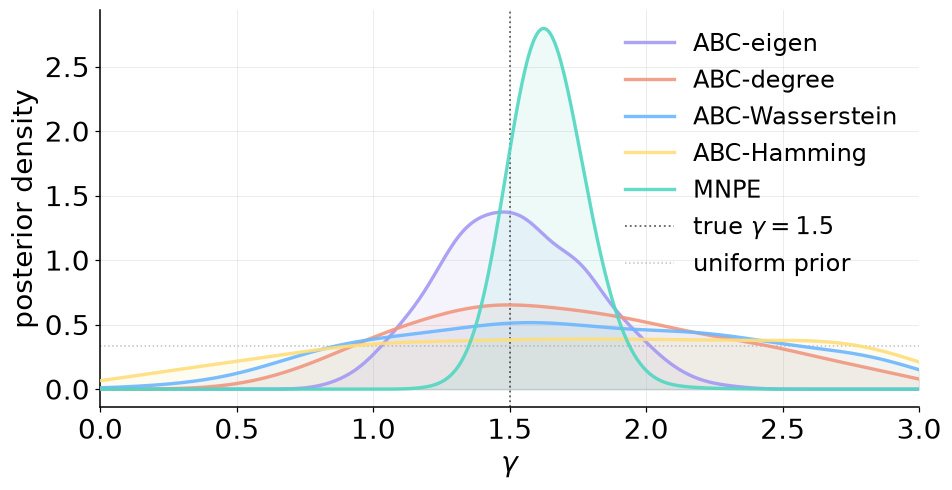

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.8))
gamma_grid = np.linspace(0, 3, 500)

# Bandwidth: Scott-rule multiplier, but never smoother than a floor in gamma units.
# This stops the exact/MNPE posteriors from being drawn as spikes.
BW_MULT = 0.3
BW_MIN  = 0.08

for name in active:
    g = results[name]['gamma']
    color = METHOD_COLORS.get(name, 'gray')
    is_ref = (name == 'CER-exact')
    if len(g) < 30:
        ax.hist(g, bins=15, density=True, alpha=0.35, color=color,
                histtype='stepfilled', label=name)
        ax.hist(g, bins=15, density=True, color=color,
                histtype='step', lw=1.6)
    else:
        std = g.std(ddof=1)
        bw  = max(BW_MULT, BW_MIN / std) if std > 0 else BW_MULT
        kde = gaussian_kde(g, bw_method=bw)
        ax.plot(gamma_grid, kde(gamma_grid),
                lw=2.6 if is_ref else 2.2,
                ls='--' if is_ref else '-',
                color=color, label=name,
                alpha=1.0 if is_ref else 0.9,
                zorder=5 if is_ref else 3)
        if not is_ref:
            ax.fill_between(gamma_grid, kde(gamma_grid), alpha=0.10, color=color)

ax.axvline(gamma_true, color='black', ls=':', lw=1.2, alpha=0.6,
           label=fr'true $\gamma = {gamma_true}$')
ax.axhline(1/3, color='#999', ls=':', lw=1.0, alpha=0.6,
           label='uniform prior')

ax.set_xlabel(r'$\gamma$')
ax.set_ylabel('posterior density')
ax.set_xlim(0, 3)
ax.legend(loc='upper right', ncol=1, framealpha=0.0)
plt.tight_layout()
plt.savefig('gamma_posterior.svg', bbox_inches='tight')
plt.show()

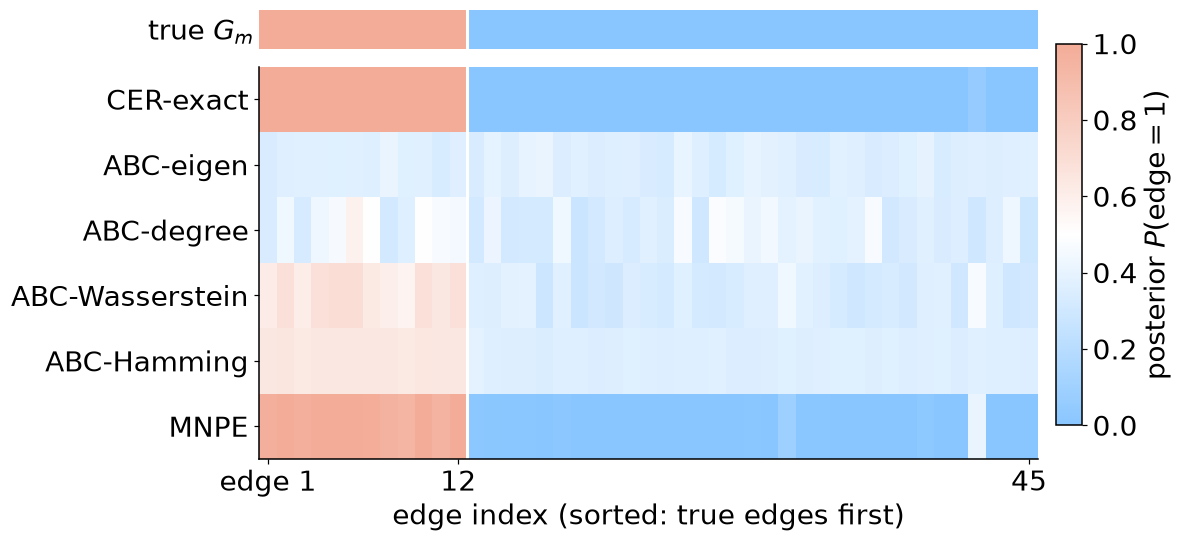

In [ ]:
edge_probs = np.stack([results[m]['Gm'].mean(axis=0) for m in active])   # (M, e)


order = np.argsort(-Gm, kind='stable')
edge_probs_s = edge_probs[:, order]
truth_s      = Gm[order]
n_true       = int(truth_s.sum())

fig = plt.figure(figsize=(11, 0.55*len(active) + 2.0))
gs  = fig.add_gridspec(2, 1, height_ratios=[0.6, 6], hspace=0.08)
ax_top = fig.add_subplot(gs[0])
ax     = fig.add_subplot(gs[1])

#colour map
import matplotlib.colors as mcolors

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#89c6ff', '#ffffff', '#f3ac97'] )

# truth strip
ax_top.imshow(truth_s[None, :], aspect='auto',
              cmap=mpl.colors.ListedColormap(['#89c6ff', '#f3ac97']))
ax_top.set_yticks([0]); ax_top.set_yticklabels(['true $G_m$'], fontsize=18)
ax_top.set_xticks([])
ax_top.tick_params(axis='y', length=0)
for s in ('top','right','bottom','left'):
    ax_top.spines[s].set_visible(False)
ax_top.axvline(n_true - 0.5, color='white', lw=2)

# main heatmap
im = ax.imshow(edge_probs_s, aspect='auto', cmap=custom_cmap,
               vmin=0, vmax=1, interpolation='nearest')
ax.set_yticks(range(len(active))); ax.set_yticklabels(active)
ax.set_xticks([0, n_true - 1, len(Gm) - 1])
ax.set_xticklabels(['edge 1', f'{n_true}', f'{len(Gm)}'])
ax.set_xlabel('edge index (sorted: true edges first)')
ax.axvline(n_true - 0.5, color='white', lw=2)
for s in ('top','right'):
    ax.spines[s].set_visible(False)
ax.grid(False)
ax_top.grid(False)

cbar = fig.colorbar(im, ax=[ax_top, ax], shrink=0.85, pad=0.02, aspect=15)
cbar.set_label(r'posterior $P(\mathrm{edge}=1)$')
plt.savefig('edge+heatmap.svg', bbox_inches='tight')
plt.show()


Hamming distance between each method's posterior-mode $G_m$ and the truth.

In [ ]:
print(f'{"method":<20s}  {"Hamming":>7s}  {"posterior γ mean":>18s}  {"post γ 95% CI":>20s}')
print('-'*72)
for name in active:
    g = results[name]['gamma']
    p = results[name]['Gm'].mean(axis=0)
    mode = (p > 0.5).astype(int)
    h = networks.hamming(mode, Gm)
    lo, hi = np.percentile(g, [2.5, 97.5])
    print(f'{name:<20s}  {h:>7d}  {g.mean():>18.3f}  [{lo:>6.3f}, {hi:>6.3f}]')

method                Hamming    posterior γ mean         post γ 95% CI
------------------------------------------------------------------------
CER-exact                   0               1.548  [ 1.367,  1.723]
ABC-eigen                  12               1.518  [ 1.041,  2.038]
ABC-degree                 11               1.719  [ 0.786,  2.830]
ABC-Wasserstein             0               1.738  [ 0.599,  2.908]
ABC-Hamming                 0               1.704  [ 0.226,  2.954]
MNPE                        0               1.639  [ 1.418,  1.895]


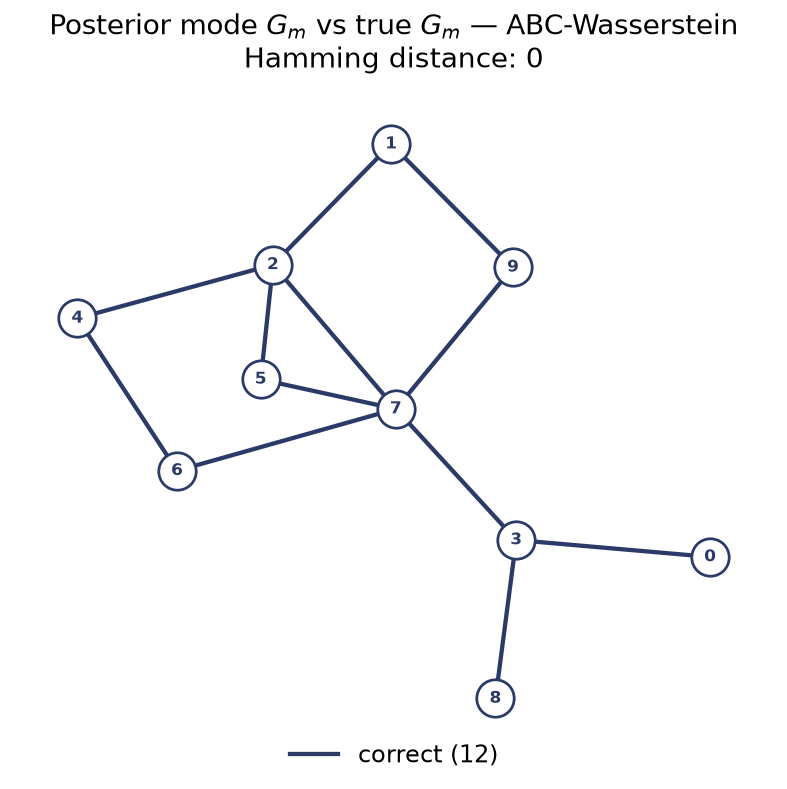

In [ ]:
SHOW_METHOD_FOR_NETWORK = 'ABC-Wasserstein'    # <- pick any active method

def plot_network_diff(method_name, Gm_true, results, N,
                      pos=None, ax=None, figsize=(7.5, 7.5),
                      show_legend=True, title_style='full'):
    p    = results[method_name]['Gm'].mean(axis=0)
    Gm_mode = (p > 0.5).astype(int)

    edge_list  = list(combinations(range(N), 2))
    true_edges = {edge_list[i] for i in range(len(Gm_true)) if Gm_true[i] == 1}
    mode_edges = {edge_list[i] for i in range(len(Gm_true)) if Gm_mode[i] == 1}
    tp = true_edges & mode_edges
    fn = true_edges - mode_edges
    fp = mode_edges - true_edges

    if pos is None:
        
        G_union = nx.Graph(); G_union.add_nodes_from(range(N))
        G_union.add_edges_from(true_edges | mode_edges)
        pos = (nx.kamada_kawai_layout(G_union)
               if G_union.number_of_edges() > 0
               else nx.circular_layout(range(N)))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    G_nodes = nx.Graph(); G_nodes.add_nodes_from(range(N))
    nx.draw_networkx_nodes(G_nodes, pos, ax=ax, node_size=600,
                           node_color='white', edgecolors='#2b3a67',
                           linewidths=1.8)
    nx.draw_networkx_labels(G_nodes, pos, ax=ax,
                            font_size=11, font_color='#2b3a67',
                            font_weight='bold')

    def _draw(edges, color, style='solid', lw=2.5, alpha=1.0, label=None):
        if not edges: return
        Gt = nx.Graph(); Gt.add_nodes_from(range(N)); Gt.add_edges_from(edges)
        nx.draw_networkx_edges(Gt, pos, ax=ax, edgelist=list(edges),
                               edge_color=color, style=style,
                               width=lw, alpha=alpha)
        if show_legend:
            ax.plot([], [], color=color,
                    ls='--' if style == 'dashed' else '-',
                    lw=lw, alpha=alpha, label=label)

    _draw(tp, '#2b3a67', 'solid',  2.8,       label=f'correct ({len(tp)})')
    _draw(fn, '#d62728', 'dashed', 2.4, 0.85, label=f'missed – true only ({len(fn)})')
    _draw(fp, '#e07a5f', 'solid',  2.4, 0.90, label=f'spurious – mode only ({len(fp)})')

    ax.set_axis_off()
    ax.grid(False)
    h = networks.hamming(Gm_mode, Gm_true)
    if title_style == 'full':
        ax.set_title(f'Posterior mode $G_m$ vs true $G_m$ — {method_name}\n'
                     f'Hamming distance: {h}',
                     pad=12)
    else:   
        ax.set_title(f'{method_name}  ·  Hamming = {h}\n'
                     f'correct {len(tp)} · missed {len(fn)} · spurious {len(fp)}',
                     pad=8, fontsize=11)
    if show_legend:
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05),
                  ncol=3, frameon=False)
    return pos

_ = plot_network_diff(SHOW_METHOD_FOR_NETWORK, Gm, results, N)
plt.tight_layout()
plt.savefig('network_diff.svg', bbox_inches='tight')
plt.show()

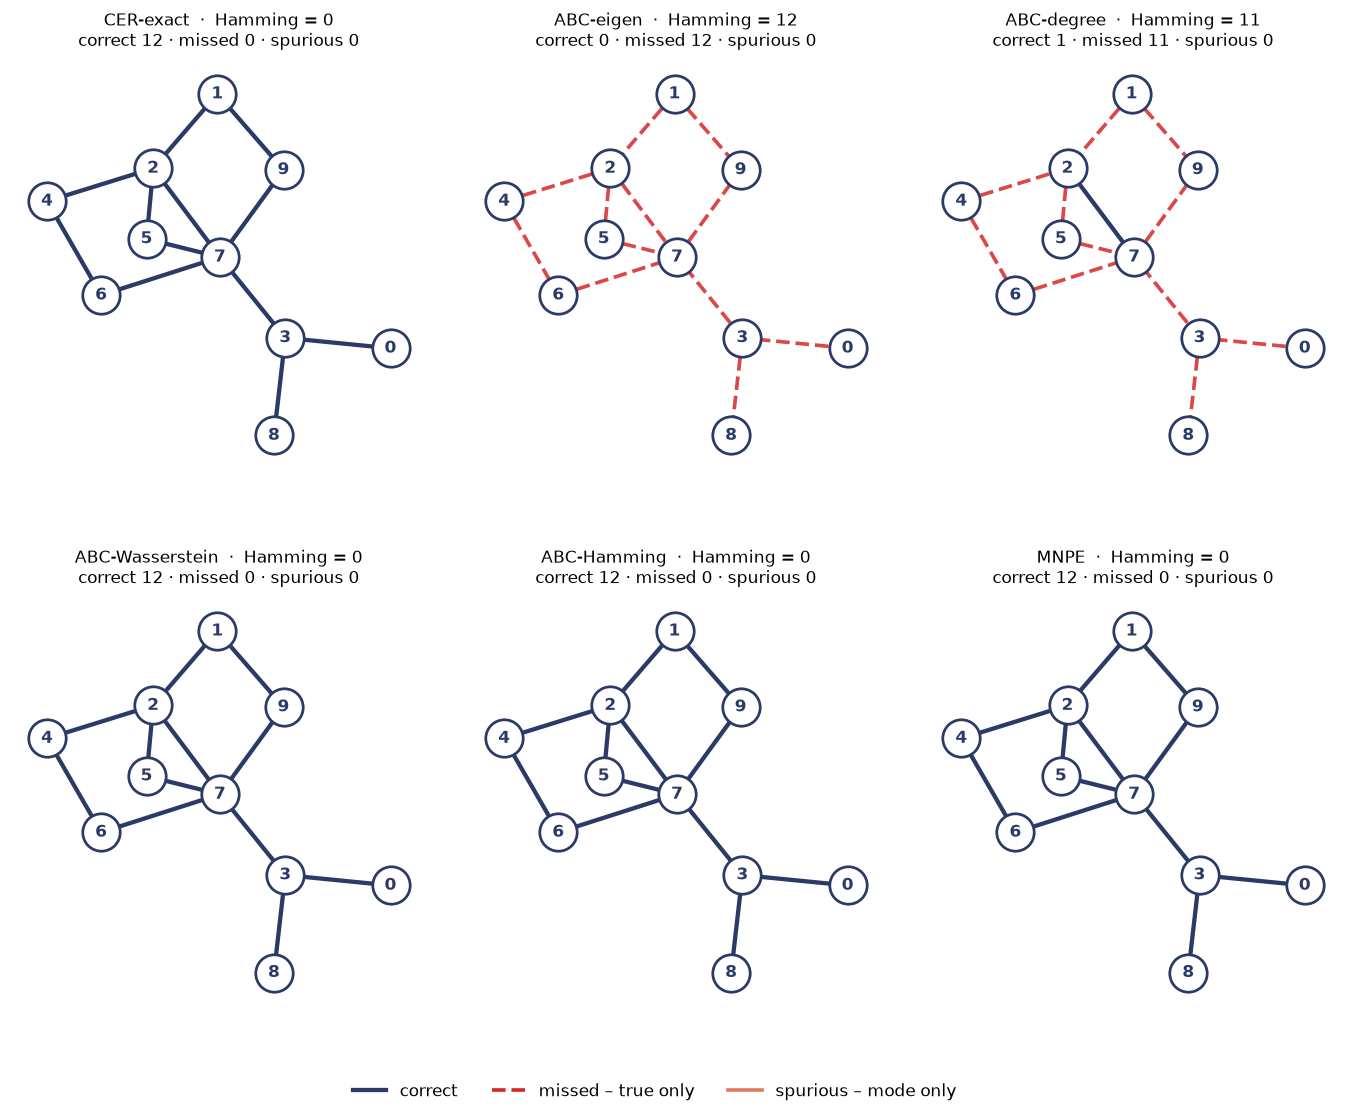

In [ ]:
n = len(active)
cols = min(3, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5.2*cols, 5.4*rows))
axes = np.atleast_1d(axes).ravel()


G_union = nx.Graph(); G_union.add_nodes_from(range(N))
el = list(combinations(range(N), 2))
G_union.add_edges_from([el[i] for i in range(len(Gm)) if Gm[i] == 1])
for m in active:
    p = results[m]['Gm'].mean(axis=0); mode = (p > 0.5).astype(int)
    G_union.add_edges_from([el[i] for i in range(len(Gm)) if mode[i] == 1])
pos_shared = (nx.kamada_kawai_layout(G_union) if G_union.number_of_edges() > 0
              else nx.circular_layout(range(N)))

for ax, m in zip(axes, active):
    plot_network_diff(m, Gm, results, N, pos=pos_shared, ax=ax,
                      show_legend=False, title_style='compact')
for ax in axes[n:]:
    ax.set_visible(False)


from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], color='#2b3a67', lw=2.8, label='correct'),
    Line2D([0],[0], color='#d62728', lw=2.4, ls='--', label='missed – true only'),
    Line2D([0],[0], color='#e07a5f', lw=2.4, label='spurious – mode only'),
]
fig.legend(handles=legend_elems, loc='lower center',
           bbox_to_anchor=(0.5, -0.01), ncol=3, frameon=False, fontsize=11)

plt.subplots_adjust(hspace=0.30, wspace=0.10, bottom=0.08)
plt.show()